This project is about credit analytics for consumer loans. The goal is to estimate risk profiles of individuals applying for a loan. For simplicity, we work with artificially generated data and only consider three borrower characteristics: age, monthly income and employment status. In reality, the availability of good data is important, and typically, many more features are taken into account.

In [1]:
import numpy as np
import pandas as pd
np.random.seed(0)

m = 20000
n = 10000

ages = np.random.uniform(18, 80, m + n)
salaries = np.random.uniform(1,15, m + n)
self_employed = np.random.choice([1,0], size = n + m, p = [0.1, 0.9])

In [2]:
#1 a) 

age_means = np.mean(ages[:m])
age_std = np.std(ages[:m])
salary_means = np.mean(salaries[:m])
salary_std = np.std(salaries[:m])
self_emp_means = np.mean(self_employed[:m])
self_emp_std = np.std(self_employed[:m])

vars = [age_std, salary_std, self_emp_std]
print(age_means, salary_means, self_emp_means)

48.74265389697123 7.986522193349889 0.09835


In [57]:
# 1 b)

# Your history with other loans, the amount of money in your savings acount, 

# 2 
sigmoid = lambda x: 1. / (1. + np.exp(-x))

xi = np.random.uniform(0,1, m + n)

p1 = 13.3 - 0.33*ages + 3.5*salaries - 3*self_employed
p1 = sigmoid(p1)

p2 = 5 - 10*((ages < 25).astype(int) + (ages > 75).astype(int)) + 1.1*salaries - self_employed
p2 = sigmoid(p2)

y1 = (xi <= p1).astype(int)

y2 = (xi <= p2).astype(int)

X_data = pd.DataFrame({
    'Age': ages[:m],
    'Salary': salaries[:m],
    'Self Employed': self_employed[:m]
})

X_test = pd.DataFrame({
    'Age': ages[m+1:m+n],
    'Salary': salaries[m+1:m+n],
    'Self Employed': self_employed[m+1:m+n]
})

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

In [58]:
# 2 a)

model1 = LogisticRegression().fit(X_data, y1[:m])
model2 = LogisticRegression().fit(X_data, y2[:m])

#print(model1.coef_[0][0], model1.intercept_[0])
"# \"pred_X = model.predict_proba(X)\" evaluates the model\n",
pred1_train = model1.predict_proba(X_data)
pred2_train = model2.predict_proba(X_data)

pred1_test = model1.predict_proba(X_test)
pred2_test = model2.predict_proba(X_test)

log_loss1 = log_loss(y1[:m], pred1_train)
log_loss2 = log_loss(y2[:m], pred2_train)

log_loss_pred1 = log_loss(y1[m+1:m+n], pred1_test)
log_loss_pred2 = log_loss(y2[m+1:m+n], pred2_test)


In [8]:
# 2 b)

#i), ii)
from sklearn.svm import SVC

GAMMA = 0.1

lamb = 5/(2*m)
C = 0.2
X_data_norm = pd.DataFrame({
    'Age': ages[:m] / age_std,
    'Salary': salaries[:m] / salary_std,
    'Self Employed': self_employed[:m] / self_emp_std
})

X_test_norm = pd.DataFrame({
    'Age': ages[m+1:m+n] / age_std,
    'Salary': salaries[m+1:m+n] / salary_std,
    'Self Employed': self_employed[m+1:m+n] / self_emp_std
})

model_svc1 = SVC(kernel='rbf', gamma=GAMMA, C=C, probability=True)

model_svc1.fit(X_data_norm, y1[:m])

model_svc2 = SVC(kernel='rbf', gamma=GAMMA, C=C, probability=True)
model_svc2.fit(X_data_norm, y2[:m])


#iii)

SVC_pred1 = model_svc1.predict_proba(X_data_norm)
SVC_pred2 = model_svc2.predict_proba(X_data_norm)

SVC_pred1_test = model_svc1.predict_proba(X_test_norm)
SVC_pred2_test = model_svc2.predict_proba(X_test_norm)


log_loss_comb1_train = log_loss(y1[:m], SVC_pred1)
log_loss_comb2_train = log_loss(y2[:m], SVC_pred2)

log_loss_comb1_test = log_loss(y1[m+1:m+n], SVC_pred1_test)
log_loss_comb2_test = log_loss(y2[m+1:m+n], SVC_pred2_test)

print(log_loss_comb2_test)
print(pred1_test)

0.06685632784979692
[[1.80526670e-05 9.99981947e-01]
 [0.00000000e+00 1.00000000e+00]
 [0.00000000e+00 1.00000000e+00]
 ...
 [1.56609414e-01 8.43390586e-01]
 [1.53113988e-04 9.99846886e-01]
 [3.33745298e-06 9.99996663e-01]]


In [69]:
# 2 c)

import matplotlib.pyplot as plt

ths = np.linspace(0, 1, 100)



p1 = np.sum(y1[m+1:m+n])
p2 = np.sum(y2[m+1:m+n])

def rates(y, p, c, p_sum):
    y_hat = (p >= c).astype(int)
    fp = np.sum(np.logical_and(y_hat, np.logical_not(y)))
    tp = np.sum(np.logical_and(y_hat,  y))
    fdr = fp / (fp + tp)
    tpr = tp / p_sum
    return([fdr, tpr])

l = len(ths)
fdr1_log = np.zeros(l) 
tpr1_log = np.zeros(l)

fdr2_log = np.zeros(l)
tpr2_log = np.zeros(l)

fdr1_comb = np.zeros(l)
tpr1_comb = np.zeros(l)

fdr2_comb = np.zeros(l)
tpr2_comb = np.zeros(l)


for i in range(0, l-1):
    both = rates(y1[m+1:m+n], pred1_test[:, 0], ths[i], p1)
    fdr1_log[i] = both[0]
    tpr1_log[i] = both[1]
    both = rates(y2[m+1:m+n], pred1_test[:, 0], ths[i], p2)
    fdr2_log[i] = both[0]
    tpr2_log[i] = both[1]
    both = rates(y1[m+1:m+n], SVC_pred1_test[:, 0], ths[i], p1)
    fdr1_comb[i] = both[0]
    tpr1_comb[i] = both[1]
    both = rates(y2[m+1:m+n], SVC_pred2_test[:, 0], ths[i], p2)
    fdr2_comb[i] = both[0]
    tpr2_comb[i] = both[1]    

print(tpr2_comb)



[1.00000000e+00 1.51090507e-01 1.10947213e-01 9.05067959e-02
 7.96544094e-02 6.99610157e-02 6.36392372e-02 5.86871773e-02
 5.33136656e-02 4.88884206e-02 4.57275313e-02 4.35149089e-02
 4.11969234e-02 3.86682120e-02 3.75092193e-02 3.59287746e-02
 3.40322411e-02 3.27678854e-02 3.11874407e-02 3.04498999e-02
 2.91855442e-02 2.80265515e-02 2.67621958e-02 2.58139290e-02
 2.48656622e-02 2.42334844e-02 2.34959435e-02 2.28637657e-02
 2.23369508e-02 2.14940470e-02 2.08618691e-02 2.00189653e-02
 1.89653356e-02 1.84385207e-02 1.82277948e-02 1.74902539e-02
 1.69634390e-02 1.66473501e-02 1.61205352e-02 1.56990833e-02
 1.49615425e-02 1.45400906e-02 1.40132757e-02 1.34864609e-02
 1.33810979e-02 1.32757349e-02 1.29596460e-02 1.25381941e-02
 1.21167422e-02 1.16952903e-02 1.13792013e-02 1.07470235e-02
 1.04309346e-02 9.90411969e-03 9.69339374e-03 9.06121589e-03
 9.06121589e-03 9.06121589e-03 9.06121589e-03 8.42903804e-03
 8.32367506e-03 7.90222316e-03 7.48077126e-03 7.27004531e-03
 6.95395638e-03 6.848593

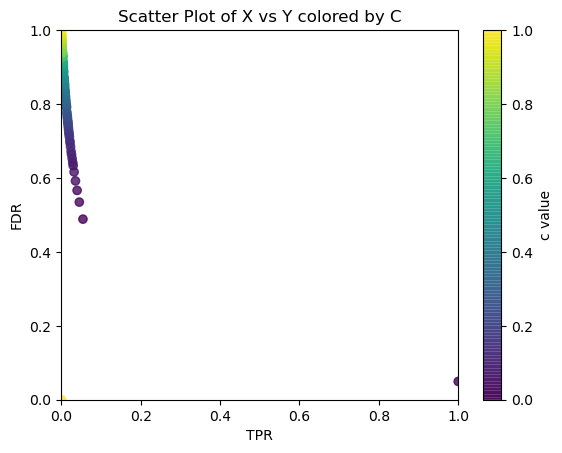

In [70]:
# Create a scatter plot
plt.scatter(tpr1_log, fdr1_log, c=ths, cmap='viridis', alpha=0.8)  # Use 'viridis' colormap
plt.colorbar(label='c value')  # Show color scale

# Set limits and labels
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('TPR')
plt.ylabel('FDR')
plt.title('Scatter Plot of X vs Y colored by C')

# Show the plot
plt.show()

In [72]:
def riem_sum(a,b):
    sum = 0
    for i in range (0,len(b) - 2):
        sum += 0.5*(b[i] + b[i+1])*(a[i+1] - a[i])
    return(sum)

sum_log1 = riem_sum(tpr1_log, fdr1_log)
print(tpr1_log)

[1.00000000e+00 5.42872173e-02 4.51341399e-02 3.95581273e-02
 3.54550237e-02 3.19831668e-02 2.96685955e-02 2.86165176e-02
 2.71436086e-02 2.55654918e-02 2.44082062e-02 2.30405050e-02
 2.18832194e-02 2.12519726e-02 2.00946870e-02 1.93582325e-02
 1.89374014e-02 1.82009469e-02 1.75697002e-02 1.70436612e-02
 1.65176223e-02 1.62019989e-02 1.58863756e-02 1.52551289e-02
 1.48342977e-02 1.43082588e-02 1.37822199e-02 1.28353498e-02
 1.26249342e-02 1.23093109e-02 1.19936875e-02 1.15728564e-02
 1.11520252e-02 1.08364019e-02 1.03103630e-02 9.99473961e-03
 9.57390847e-03 9.15307733e-03 9.04786954e-03 8.62703840e-03
 8.10099947e-03 7.78537612e-03 7.57496055e-03 7.36454498e-03
 6.94371383e-03 6.83850605e-03 6.73329826e-03 6.52288269e-03
 6.52288269e-03 6.10205155e-03 5.57601262e-03 5.36559705e-03
 5.15518148e-03 4.73435034e-03 4.62914256e-03 4.52393477e-03
 4.52393477e-03 4.41872699e-03 4.10310363e-03 3.78748027e-03
 3.78748027e-03 3.78748027e-03 3.57706470e-03 3.26144135e-03
 3.05102578e-03 2.945817

In [ ]:
s = 50000

D = np.zeros((n, s))

for k in range(0, s-1):
    xi = np.random.uniform(0,1,n)
    D[:,k] = (xi <= pred2_test).astype(int) 

#Strategy 1

w1 = np.zeros(s)

for k in range(0, s-1):
    pb = 55*np.sum(D[:,k])
    npb = -1000*(n - np.sum(D[:,k]))
    w1[k] = pb + npb

plt.bar(np.arange(1, 50001), w1)
#Strategy 2



